# Pandas Timeseries

Subtitle: **How to handle time series data with ease**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
url = "https://github.com/pandas-dev/pandas/tree/main/doc/data/air_quality_no2_long.csv"
air_quality = pd.read_csv(
    url.replace("tree", "raw"),
).rename(columns={"date.utc": "datetime"})
air_quality.head()

,city,country,datetime,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


Initially, the values in datetime are character strings and do not provide any datetime operations (e.g. extract the year, day of the week, …). we could have used the `pd.to_datetime(col)` to convert:

In [4]:
air_quality["datetime"] = pd.to_datetime(air_quality["datetime"])

What is the start and end date of the time series data set we are working with?

In [5]:
air_quality["datetime"].min(), air_quality["datetime"].max()

(Timestamp('2019-05-07 01:00:00+0000', tz='UTC'),
 Timestamp('2019-06-21 00:00:00+0000', tz='UTC'))

Using [`pandas.Timestamp`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Timestamp.html#pandas.Timestamp "pandas.Timestamp") for datetimes enables us to calculate with date information and make them comparable. Hence, we can use this to get the length of our time series:

In [6]:
air_quality["datetime"].max() - air_quality["datetime"].min()

Timedelta('44 days 23:00:00')

Notice the result of subtraction was a [`pandas.Timedelta`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Timedelta.html#pandas.Timedelta "pandas.Timedelta") object, similar to `datetime.timedelta` from the standard Python library which defines a time duration.

Sometimes it is helpful to refer to individual components.

E.g., say we want to add a new column to the DataFrame containing only the month of the measurement:

In [9]:
air_quality["datetime"].dt.month

0       6
1       6
2       6
3       6
4       6
       ..
2063    5
2064    5
2065    5
2066    5
2067    5
Name: datetime, Length: 2068, dtype: int32

In [7]:
air_quality["month"] = air_quality["datetime"].dt.month
air_quality.head()

,city,country,datetime,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


By using `Timestamp` objects for dates, a lot of time-related properties are provided by pandas. For example the `month`, but also `year`, `quarter`,… All of these properties are accessible by the `dt` accessor.

An overview of the existing date properties is given in the [time and date components overview table](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-components). More details about the `dt` accessor to return datetime like properties are explained in a dedicated section on the [dt accessor](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-dt-accessors).

Let's say we want to know what is the average $NO_2$ concentration for each day of the week for each of the measurement locations:

In [40]:
air_quality.groupby(
    [air_quality['datetime'].dt.weekday, "location"])["value"].mean()

datetime  location          
0         BETR801               27.875000
          FR04014               24.856250
          London Westminster    23.969697
1         BETR801               22.214286
          FR04014               30.999359
          London Westminster    24.885714
2         BETR801               21.125000
          FR04014               29.165753
          London Westminster    23.460432
3         BETR801               27.500000
          FR04014               28.600690
          London Westminster    24.780142
4         BETR801               28.400000
          FR04014               31.617986
          London Westminster    26.446809
5         BETR801               33.500000
          FR04014               25.266154
          London Westminster    24.977612
6         BETR801               21.896552
          FR04014               23.274306
          London Westminster    24.859155
Name: value, dtype: float64

> Remember the split-apply-combine pattern provided by `groupby` from the [tutorial on statistics calculation](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/06_calculate_statistics.html#min-tut-06-stats)? Here, we want to calculate a given statistic (e.g. mena $NO_2$) **for each weekday** and **for each measurement location**. To group on weekdays, we use the datetime property `weekday` (with Monday=0 and Sunday=6) of pandas `Timestamp`, which is also accessible by the `dt` accessor. The grouping on both locations and weekdays can be done to split the calculation of the mean on each of these combinations.

Let's plot the typical $NO_2$ pattern during the day of our time series of all stations together. In other words, what is the average value for each hour of the day?

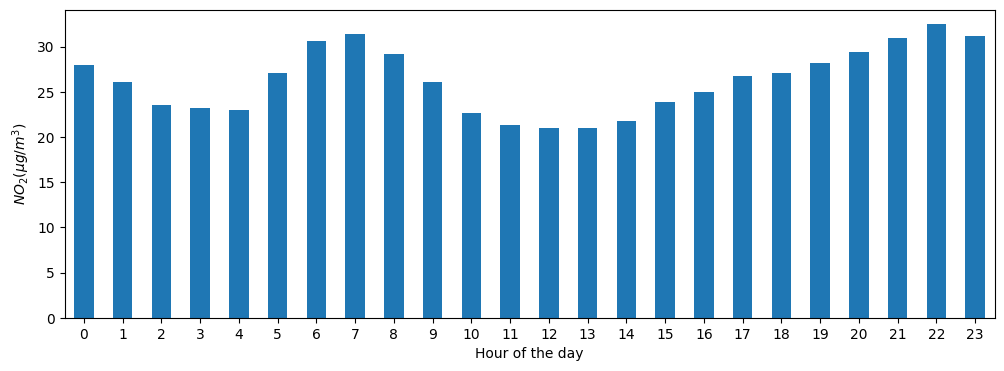

In [46]:
fig, axs = plt.subplots(figsize=(12, 4))

air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean()\
    .plot(kind='bar', rot=0, ax=axs)
plt.xlabel("Hour of the day")
plt.ylabel("$NO_2 (µg/m^3)$");

> Similar to the previous case, we want to calculate a given statistic (e.g. mean $NO_2$) **for each hour of the day** and we can use the split-apply-combine approach again. For this case, we use the datetime property `hour` of pandas `Timestamp`, which is also accessible by the `dt` accessor.

In the [tutorial on reshaping](./03_pd_reshape.ipynb), [`pivot()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot.html#pandas.pivot) was introduced to reshape the data table with each of the measurements locations as a separate column:

In [47]:
no_2 = air_quality.pivot(
    index="datetime",
    columns="location",
    values="value"
)
no_2.head()

location,BETR801,FR04014,London Westminster
datetime,,,
2019-05-07 01:00:00+00:00,50.5,25.0,23.0
2019-05-07 02:00:00+00:00,45.0,27.7,19.0
2019-05-07 03:00:00+00:00,NaN,50.4,19.0
2019-05-07 04:00:00+00:00,NaN,61.9,16.0
2019-05-07 05:00:00+00:00,NaN,72.4,NaN


Note: By pivoting the data, the datetime information became the index of the table. In general, setting a column as an index can be achieved by the `set_index` function.

Working with a datetime index (i.e. `DatetimeIndex`) provides powerful functionalities. For example, we do not need the `dt` accessor to get the time series properties, but have these properties available on the index directly:

In [ ]:
no_2.index.year

Index([2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019,
       ...
       2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019],
      dtype='int32', name='datetime', length=1033)

In [50]:
no_2.index.weekday

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       3, 3, 3, 3, 3, 3, 3, 3, 3, 4],
      dtype='int32', name='datetime', length=1033)

Some other advantages are the convenient subsetting of time period or the adapted time scale on plots. Let’s apply this on our data.

Create a plot of the $NO_2$ values in the different stations from May 20th till the end of May 21st. By providing a **string that parses to a datetime**, a specific subset of the data can be selected on a `DatetimeIndex`:

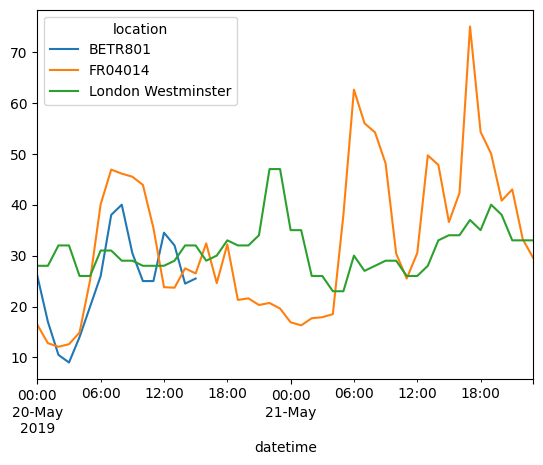

In [51]:
no_2["2019-05-20":"2019-05-21"].plot();

More information on the `DatetimeIndex` and the slicing by using strings is provided in the section on [time series indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-datetimeindex).

## Resample a time series to another frequency

A very powerful method on time series data with a datetime index, is the ability to [`resample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.resample.html#pandas.Series.resample "pandas.Series.resample") time series to another frequency (e.g., converting secondly data into 5-minutely data).

Let's aggregate the current hourly time series values to the monthly maximum value in each of the stations. 

In [52]:
monthly_max = no_2.resample("MS").max()
monthly_max

location,BETR801,FR04014,London Westminster
datetime,,,
2019-05-01 00:00:00+00:00,74.5,97.0,97.0
2019-06-01 00:00:00+00:00,52.5,84.7,52.0


The [`resample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.resample.html#pandas.Series.resample "pandas.Series.resample") method is similar to a groupby operation:

- it provides a time-based grouping, by using a string (e.g. `M`, `5H`, …) that defines the target frequency
- it requires an aggregation function such as `mean`, `max`,…

An overview of the aliases used to define time series frequencies is given in the [offset aliases overview table](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases).

When defined, the frequency of the time series is provided by the `freq` attribute:

In [53]:
monthly_max.index.freq

<MonthBegin>

Let's plot the daily mean $NO_2$ value in each of the stations:

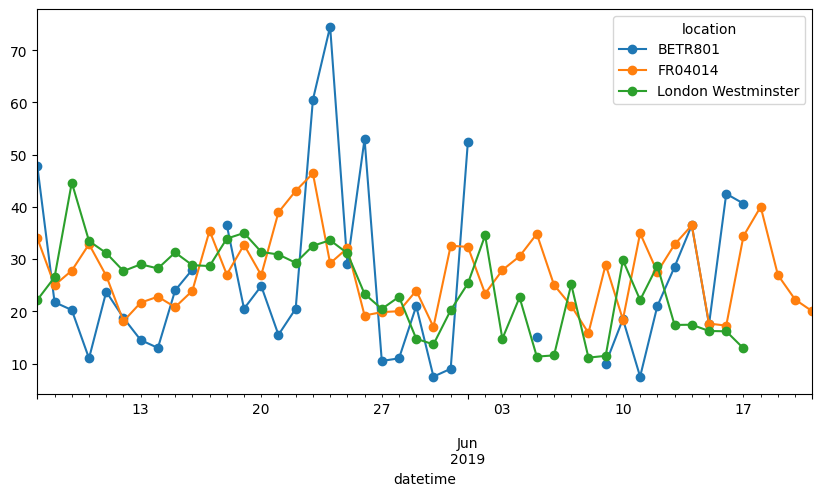

In [54]:
no_2.resample("D").mean().plot(style="-o", figsize=(10, 5));

More details on the power of time series `resampling` is provided in the user guide section on [resampling](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-resampling).

A full overview on time series is given on the pages on [time series and date functionality](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries).

---

References:

- https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/09_timeseries.html